In [9]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import missingno as msno
from pandas.plotting import scatter_matrix
from matplotlib.pyplot import figure


- Sets the precision of data to 2 decimal points
- Read the input CSV file

In [3]:
pd.set_option('display.precision', 2)

df = pd.read_csv('machine_params_and_cost_v2.csv')
print(f"df.shape = {df.shape}")

print(f"df.info() = {df.info()}")
#df.info()

df.shape = (2000, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ag                     2000 non-null   object 
 1   bg                     2000 non-null   object 
 2   T1                     1960 non-null   float64
 3   V1                     1965 non-null   float64
 4   A1                     1964 non-null   float64
 5   P1                     1967 non-null   float64
 6   B1                     1969 non-null   float64
 7   T2                     1963 non-null   float64
 8   V2                     1965 non-null   float64
 9   A2                     1950 non-null   float64
 10  P2                     1955 non-null   float64
 11  B2                     1968 non-null   float64
 12  T3                     1960 non-null   float64
 13  V3                     1967 non-null   float64
 14  A3                     1957 non-nu

In [4]:
df

,ag,bg,T1,V1,A1,P1,B1,T2,V2,A2,...,B4,Contamination_Defect,Crystalisation_Defect,Ion_Diffusion_Defect,Burnishing_Defect,m1_cost,m2_cost,m3_cost,m4_cost,ID
0,Low,Argon,93.99,445746.58,299.44,30.67,61.76,660.21,1.45e+06,468.43,...,349.56,0,0,0,0,1139.53,2064.62,1156.56,840.47,0
1,Low,Argon,57.16,389648.47,275.28,49.96,132.62,502.63,4.53e+06,435.62,...,340.56,0,1,0,0,1008.11,NaN,869.71,523.19,1
2,Medium,Argon,81.26,396609.84,235.95,15.26,130.84,501.80,2.89e+06,113.89,...,355.24,0,1,0,0,1024.36,4008.28,822.97,614.95,2
3,Medium,Neon,125.48,165185.46,221.71,14.67,116.94,437.94,2.67e+06,148.94,...,349.99,1,1,0,0,480.40,NaN,1184.28,719.92,3
4,Medium,Argon,138.01,626895.16,202.00,22.25,142.09,577.79,8.95e+05,242.34,...,332.95,0,0,0,0,1565.70,1309.50,1266.84,551.15,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Medium,Argon,75.38,293421.05,296.38,33.80,121.24,423.84,1.71e+06,214.81,...,344.83,0,0,1,0,782.01,2406.01,629.39,609.98,1995
1996,Low,Argon,127.14,559967.44,96.77,-0.97,132.54,668.87,3.26e+06,118.29,...,342.24,0,1,0,0,1408.13,4500.85,841.29,528.37,1996
1997,High,Argon,110.84,590151.68,255.16,NaN,133.59,466.33,1.43e+06,88.66,...,365.05,0,0,0,0,1479.36,2036.43,912.39,473.06,1997
1998,High,C02,48.61,410247.00,230.21,17.47,115.00,536.73,3.04e+06,201.59,...,312.21,0,1,0,0,1056.18,4202.86,1208.68,821.62,1998


In [5]:
df.loc[0:5, 'ag': 'P1']

,ag,bg,T1,V1,A1,P1
0,Low,Argon,93.99,445746.58,299.44,30.67
1,Low,Argon,57.16,389648.47,275.28,49.96
2,Medium,Argon,81.26,396609.84,235.95,15.26
3,Medium,Neon,125.48,165185.46,221.71,14.67
4,Medium,Argon,138.01,626895.16,202.00,22.25
5,Low,Neon,122.15,293819.35,138.81,38.79


In [6]:
df.iloc[0:7, 0:5]

,ag,bg,T1,V1,A1
0,Low,Argon,93.99,445746.58,299.44
1,Low,Argon,57.16,389648.47,275.28
2,Medium,Argon,81.26,396609.84,235.95
3,Medium,Neon,125.48,165185.46,221.71
4,Medium,Argon,138.01,626895.16,202.00
5,Low,Neon,122.15,293819.35,138.81
6,Medium,C02,122.02,179320.97,144.55


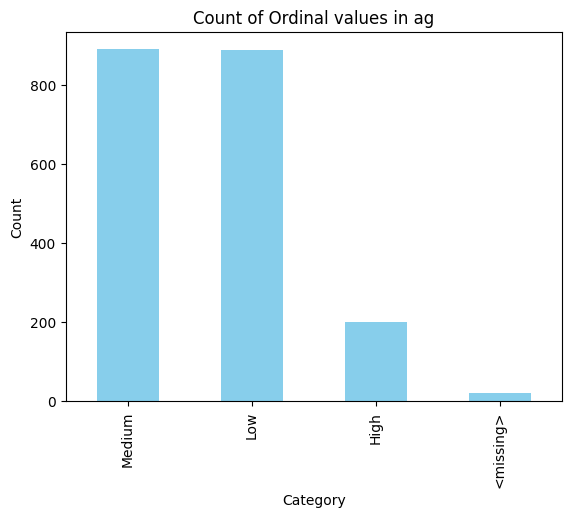

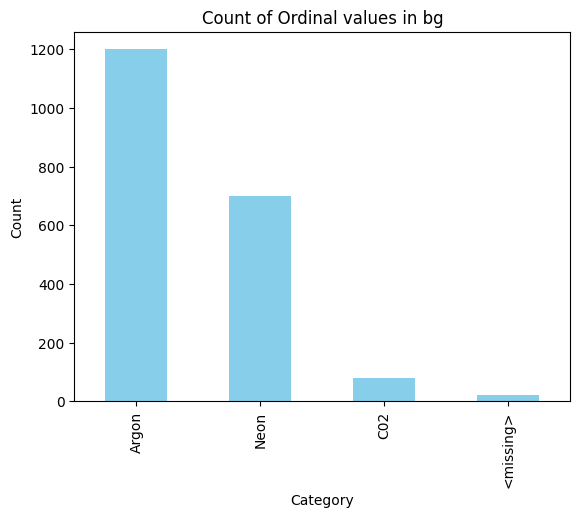

In [7]:
def count_ordinal(df, feature):
    counts = df[feature].value_counts()
    # Create a bar plot
    counts.plot(kind='bar', color='skyblue')
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.title(f'Count of Ordinal values in {feature}')
    # show the plot
    plt.show()

count_ordinal(df, 'ag')
count_ordinal(df, 'bg')



Creating the plot of Cardinal values using the SNS Plot along the Y Axis

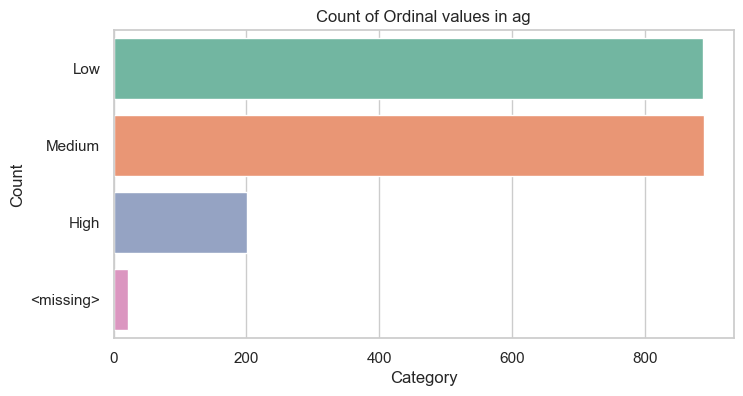

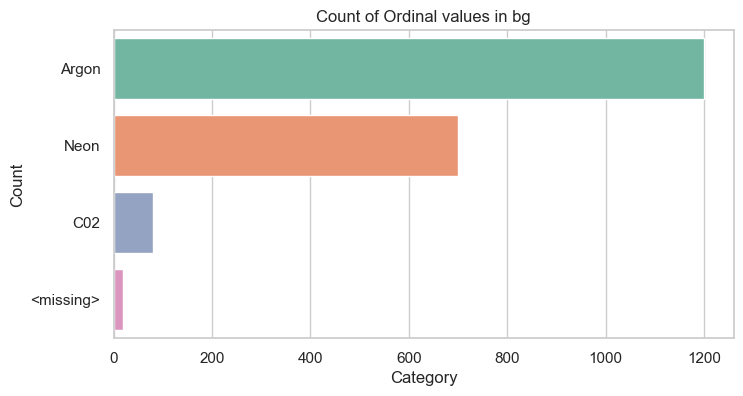

In [11]:
def count_ordinal_sns(df, feature):
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, y=feature, palette='Set2', hue=feature, legend=False)
    plt.title(f'Count of Ordinal values in {feature}')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.show()

count_ordinal_sns(df, 'ag')
count_ordinal_sns(df, 'bg')

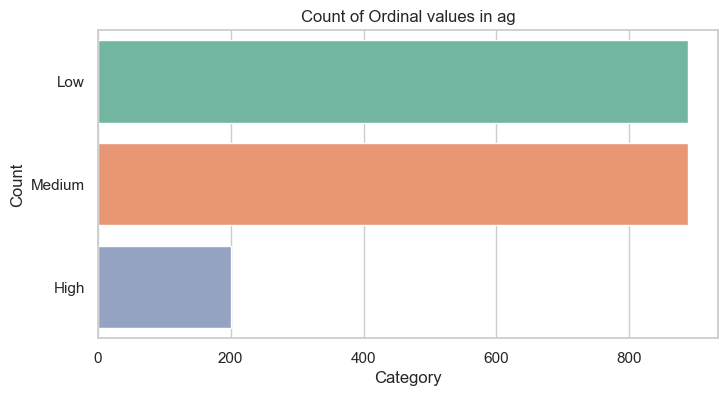

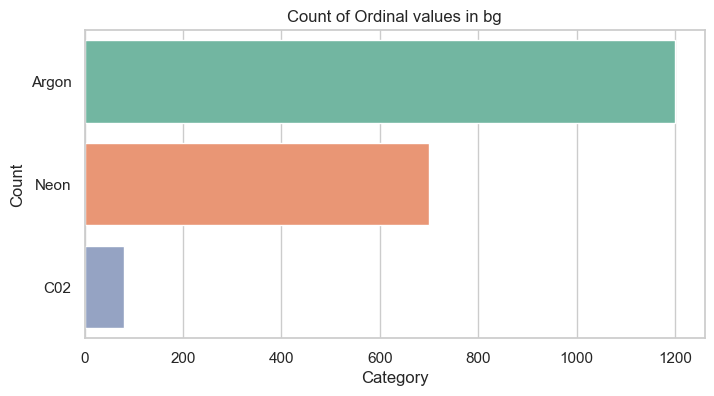

In [13]:
# Convert all columns with '<missing>' value to NaN
df = df.replace('<missing>', np.nan)

# Reprint the dataframe info to see the changes
count_ordinal_sns(df, 'ag')
count_ordinal_sns(df, 'bg')

In [15]:
# Check the df info and will see ag and bg columns have NaN values now
print("df.info() =")
df.info()

df.info() =
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ag                     1978 non-null   object 
 1   bg                     1980 non-null   object 
 2   T1                     1960 non-null   float64
 3   V1                     1965 non-null   float64
 4   A1                     1964 non-null   float64
 5   P1                     1967 non-null   float64
 6   B1                     1969 non-null   float64
 7   T2                     1963 non-null   float64
 8   V2                     1965 non-null   float64
 9   A2                     1950 non-null   float64
 10  P2                     1955 non-null   float64
 11  B2                     1968 non-null   float64
 12  T3                     1960 non-null   float64
 13  V3                     1967 non-null   float64
 14  A3                     1957 non-null   float

We can see now that ag and bg columns non-null values are no more 2000 but 1978 and 1980 resply as Nan is counted as NULL values

In [16]:
# Remove the ID field
df = df.drop(columns=['ID'])

In [ ]:
# Visualize the missing data pattern
msno.matrix(df)
plt.show()